In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from google.colab import files, userdata

In [ ]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

!pip install kaggle -q
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip gtsrb-german-traffic-sign.zip


Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
gtsrb-german-traffic-sign.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  gtsrb-german-traffic-sign.zip
replace Meta.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
DATA_PATH = "/content/"

TRAIN_PATH = os.path.join(DATA_PATH, "Train")
TEST_PATH = os.path.join(DATA_PATH, "Test")

train_csv = pd.read_csv(os.path.join(DATA_PATH, "Train.csv"))
test_csv = pd.read_csv(os.path.join(DATA_PATH, "Test.csv"))
meta_csv = pd.read_csv(os.path.join(DATA_PATH, "Meta.csv"))

In [ ]:
print("GTSRB Veri Seti Genel Bilgiler")

print(f"Eğitim örnek sayısı : {len(train_csv)}")
print(f"Test örnek sayısı : {len(test_csv)}")
print(f"Sınıf sayısı : {train_csv['ClassId'].nunique()}")


GTSRB Veri Seti Genel Bilgiler
Eğitim örnek sayısı : 39209
Test örnek sayısı : 12630
Sınıf sayısı : 43


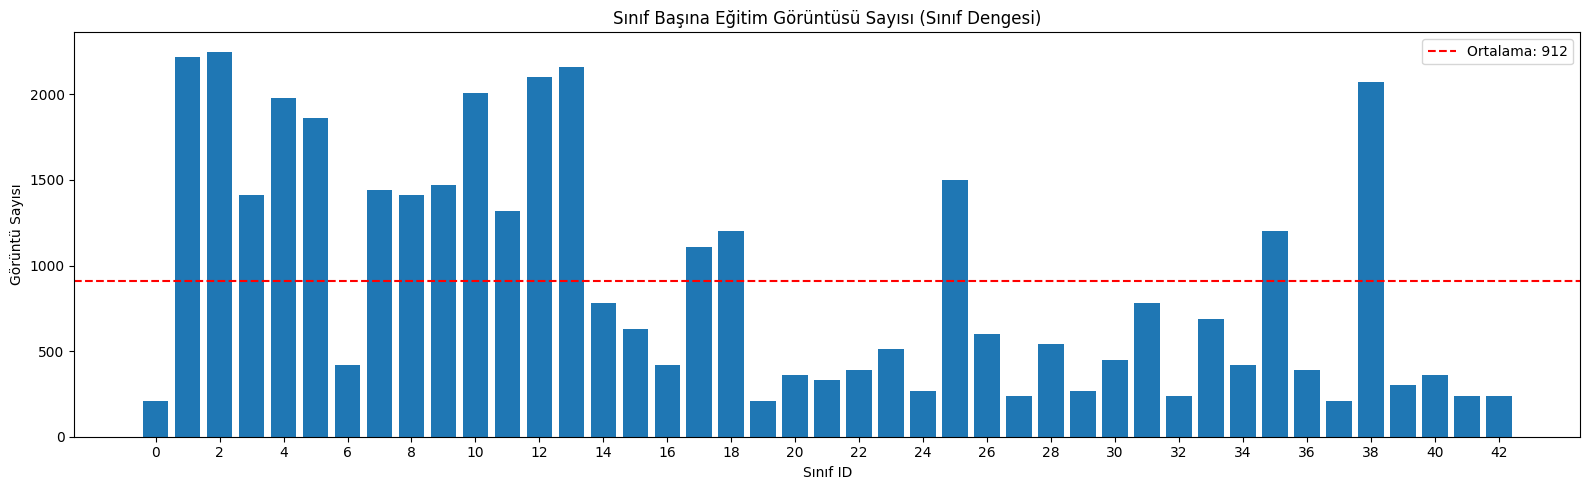


En çok örnek: Sınıf 2 -> 2250 görüntü.

En az örnek: Sınıf 0 -> 210 görüntü.
Oran: 10.7x dengesizlik.


In [ ]:
## Sınıf Dağılımı

class_counts = train_csv['ClassId'].value_counts().sort_index()

plt.figure(figsize=(16,5))
bars = plt.bar(class_counts.index, class_counts.values, linewidth=0.5)
plt.xlabel("Sınıf ID")
plt.ylabel("Görüntü Sayısı")
plt.title("Sınıf Başına Eğitim Görüntüsü Sayısı (Sınıf Dengesi)")
plt.xticks(range(0,43,2))
plt.axhline(y=class_counts.mean(), color='r', linestyle='--', label=f"Ortalama: {class_counts.mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nEn çok örnek: Sınıf {class_counts.idxmax()} -> {class_counts.max()} görüntü.")
print(f"\nEn az örnek: Sınıf {class_counts.idxmin()} -> {class_counts.min()} görüntü.")
print(f"Oran: {class_counts.max() / class_counts.min():.1f}x dengesizlik.")

In [ ]:
## Görüntü Boyutlarını İncele

print("\nGörüntü boyut istatistikleri:")
print(f"Genişlik -> min: {train_csv['Width'].min()}, max: {train_csv['Width'].max()}, ortalama: {train_csv['Width'].mean():.1f}")
print(f"Yükseklik -> min: {train_csv['Height'].min()}, max: {train_csv['Height'].max()}, ortalama: {train_csv['Height'].mean():.1f}")


Görüntü boyut istatistikleri:
Genişlik -> min: 25, max: 243, ortalama: 50.8
Yükseklik -> min: 25, max: 225, ortalama: 50.3


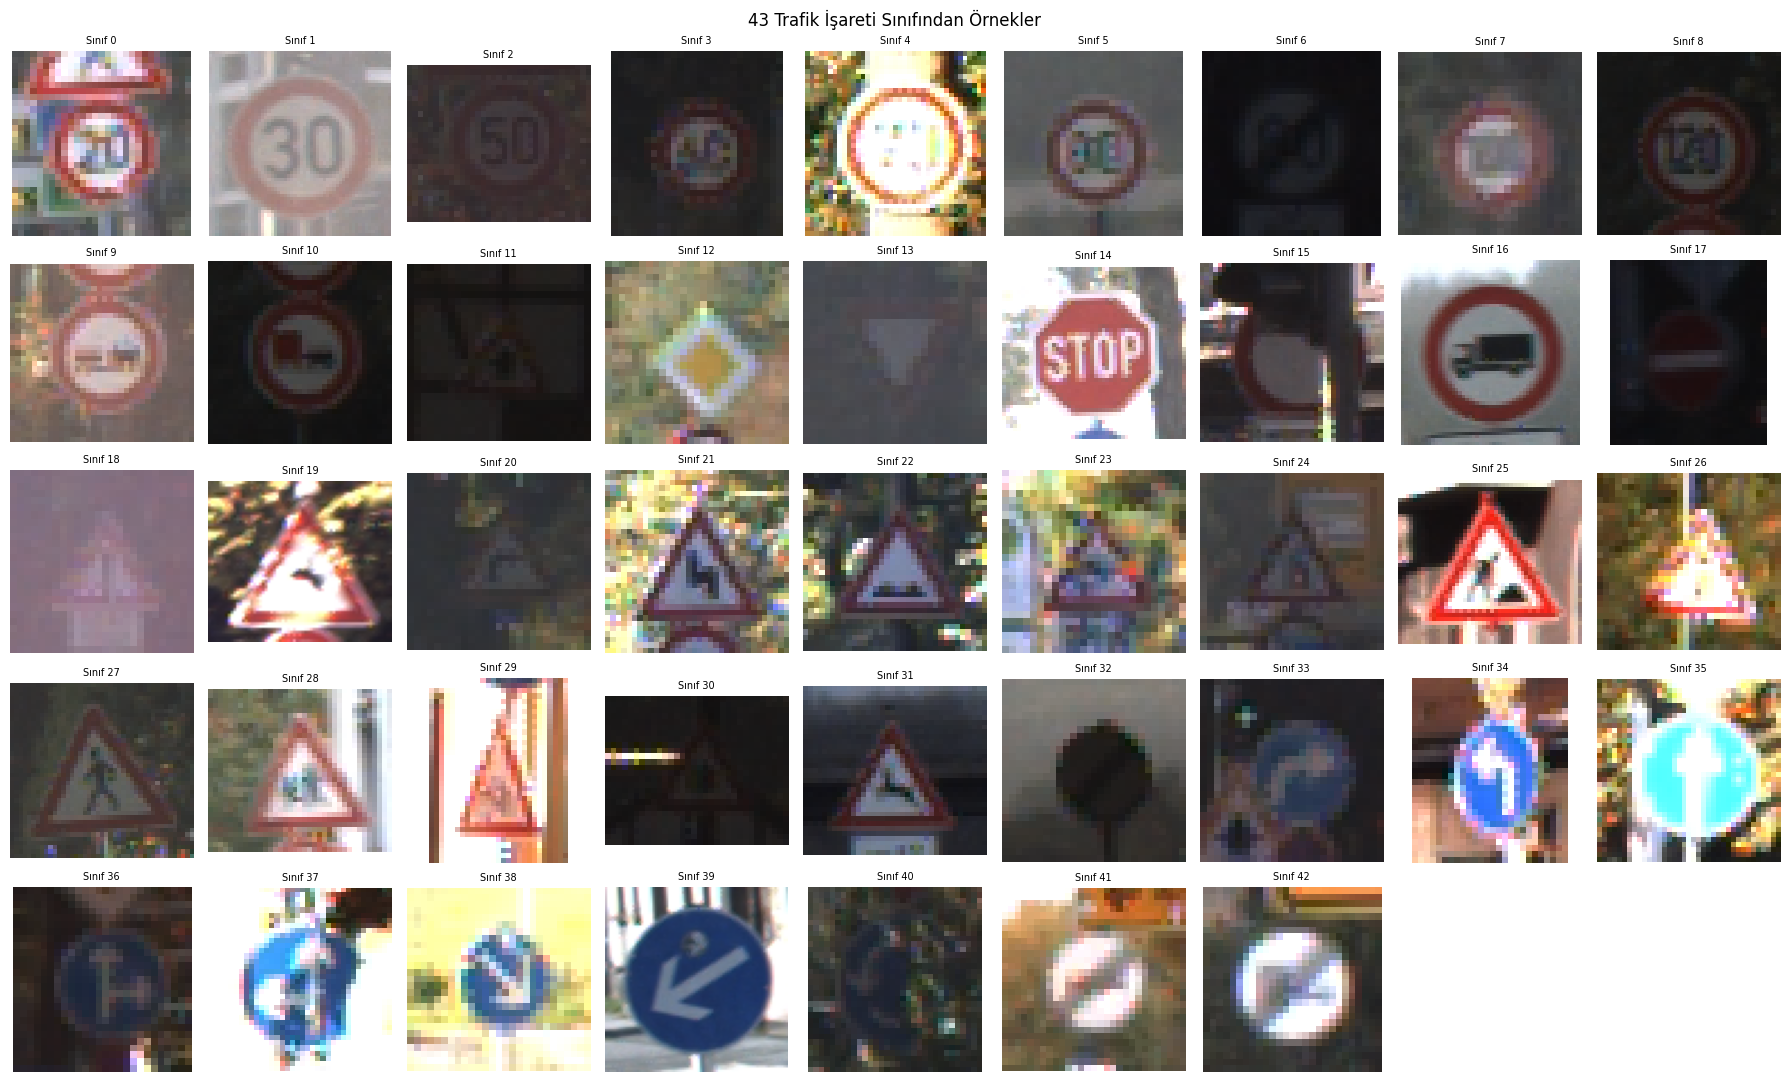

In [ ]:
## Örnek Görüntüler

fig, axes = plt.subplots(5,9, figsize=(18,11))
axes = axes.flatten()

for class_id in range(43):
    row = train_csv[train_csv['ClassId'] == class_id].iloc[0]
    img_path = os.path.join(DATA_PATH, row['Path'])
    img = Image.open(img_path)

    axes[class_id].imshow(img)
    axes[class_id].set_title(f"Sınıf {class_id}", fontsize=7)
    axes[class_id].axis('off')

for i in range(43, len(axes)):
    axes[i].axis('off')

plt.suptitle("43 Trafik İşareti Sınıfından Örnekler")
plt.tight_layout()
plt.show()


In [ ]:
IMG_SIZE = 32

# Dataframe'deki her satır için görüntüyü yükle, yeniden boyutlandır, numpy array döndür.

def load_images(df, data_path, img_size=32):
    images = []
    labels = []

    for _, row in df.iterrows():
        img_path = data_path + row['Path']
        img = Image.open(img_path).convert('RGB') # görüntüleri rgb'ye çevir
        img = img.resize((img_size, img_size)) # yeniden boyutlandır
        img_array = np.array(img, dtype='float32') / 255.0 # direkt normalizasyon

        images.append(img_array)
        labels.append(row['ClassId'])

    return np.array(images), np.array(labels)

In [ ]:
## Veriyi Yükle

X_train_full, y_train_full = load_images(train_csv, DATA_PATH)
X_test, y_test = load_images(test_csv, DATA_PATH)

print(f"\nEğitim seti şekli: {X_train_full.shape}")
print(f"Test seti şekli: {X_test.shape}")


Eğitim seti şekli: (39209, 32, 32, 3)
Test seti şekli: (12630, 32, 32, 3)


In [ ]:
## Train-Validation Split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state = 42,
    stratify=y_train_full # her sınıftan eşit oranda ayır
)

print(f"\nTrain seti : {X_train.shape[0]} görüntü")
print(f"Validation : {X_val.shape[0]} görüntü")
print(f"Test seti : {X_test.shape[0]} görüntü")


Train seti : 31367 görüntü
Validation : 7842 görüntü
Test seti : 12630 görüntü


In [ ]:
print("Normalizasyon sonrası: ")
print(f"Min piksel: {X_train.min()}")
print(f"Max piksel: {X_train.max()}")

Normalizasyon sonrası: 
Min piksel: 0.0
Max piksel: 1.0


In [ ]:
## Görüntüleri yükle, 32x32 boyutuna getir, normalize et.
X_train_full, y_train_full = load_images(train_csv, DATA_PATH)
X_test, y_test = load_images(test_csv, DATA_PATH)

(39209, 32, 32, 3)


In [ ]:
## Sınıf etiketlerini binary vektöre dönüştürme - One-Hot Encoding

NUM_CLASSES = 43
y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_val_ohe = to_categorical(y_val, NUM_CLASSES)
y_test_ohe = to_categorical(y_test, NUM_CLASSES)


Etiket şekli (önce) : 12
Etiket şekli (sonra) : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
X_train: (31367, 32, 32, 3), y_train: (31367, 43)


In [ ]:
## Veri Artırma - Augmentation

train_datagen = ImageDataGenerator(
    rotation_range=10, #  +-10 derece döndür
    zoom_range = 0.1, # %10 zoom
    width_shift_range = 0.1, # yatayda %10 kaydır
    height_shift_range = 0.1, # dikeyde %10 kaydır
    fill_mode='nearest' # dönüşüm sonrası boş pikselleri doldur
)

In [ ]:
val_datagen = ImageDataGenerator()

BATCH_SIZE = 64

train_generator = train_datagen.flow(
    X_train, y_train_ohe,
    batch_size = BATCH_SIZE,
    shuffle = True
)

val_generator = val_datagen.flow(
    X_val, y_val_ohe,
    batch_size = BATCH_SIZE,
    shuffle = False
)

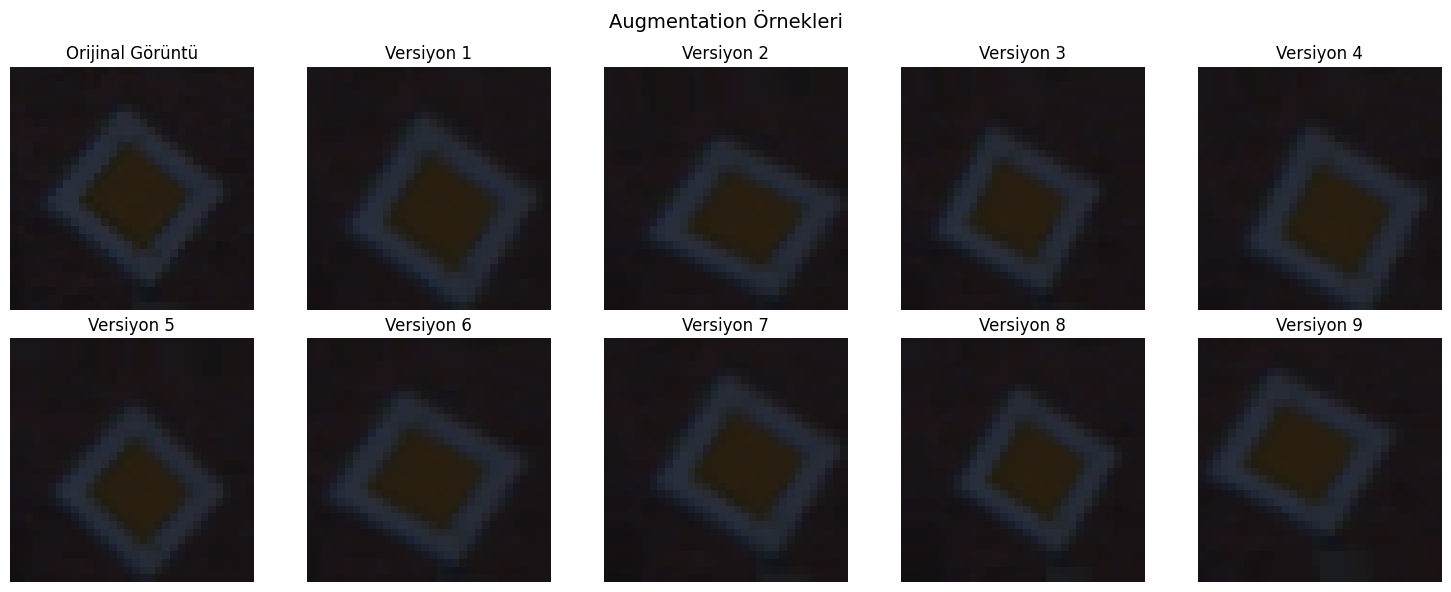

Train generator : 491 batch
Val generator : 123 batch


In [ ]:
sample_img = X_train[0:1]
sample_label = y_train_ohe[0:1]

fig,axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()

# Orijinal
axes[0].imshow(sample_img[0])
axes[0].set_title("Orijinal Görüntü")
axes[0].axis('off')

# 9 farklı augmentation versiyonu
aug_gen = train_datagen.flow(sample_img, sample_label, batch_size=1)

for i in range(1,10):
    aug_img, _ = next(aug_gen)
    axes[i].imshow(np.clip(aug_img[0], 0, 1))
    axes[i].set_title(f"Versiyon {i}")
    axes[i].axis('off')


plt.suptitle("Augmentation Örnekleri", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Train generator : {len(train_generator)} batch")
print(f"Val generator : {len(val_generator)} batch")

In [ ]:
## CNN Mimarisi

model = Sequential([

    # Blok 1
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Blok 2
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Blok 3
    Conv2D(128, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Tam Bağlantı Katmanları
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(43, activation='softmax')
])


# Mimariyi Özetle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,361,995 (5.20 MB)

 Trainable params: 1,360,075 (5.19 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

print(f"Optimizer : Adam (lr = 0.001)")
print(f"Loss : Categorical Crossentropy")
print(f"Metrik : Accuracy")

Optimizer : Adam (lr = 0.001)
Loss : Categorical Crossentropy
Metrik : Accuracy


In [ ]:
early_stop = EarlyStopping(
    monitor = 'val_loss', # validation loss'u izle
    patience = 5, # 5 epoch iyileşmezse dur
    restore_best_weights = True # en iyi ağırlıklara geri dön
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.5, # learning rate'i yarıya indir
    patience = 3, # 3 epoch iyileşmezse uygula
    min_lr = 0.00001 # en düşük learning rate
)

checkpoint = ModelCheckpoint(
    'best_model.keras', # kayıt yeri
    monitor = 'val_accuracy',
    save_best_only = True, # sadece en iyiyi kaydet
    verbose = 1
)

In [ ]:
## Eğitim

EPOCHS = 30
history = model.fit(
    train_generator,
    epochs = EPOCHS,
    validation_data = val_generator,
    callbacks = [early_stop, reduce_lr, checkpoint],
    verbose = 1
)

print("\nEğitim tamamlandı!")

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3297 - loss: 2.7081
Epoch 1: val_accuracy improved from None to 0.73183, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.5226 - loss: 1.7276 - val_accuracy: 0.7318 - val_loss: 0.8468 - learning_rate: 0.0010
Epoch 2/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8500 - loss: 0.4597
Epoch 2: val_accuracy improved from 0.73183 to 0.96123, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8852 - loss: 0.3554 - val_accuracy: 0.9612 - val_loss: 0.1239 - learning_rate: 0.0010
Epoch 3/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9414 - loss: 0.1805
Epoch 3: val_accuracy improved from 0.96123 to 0.99235, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 

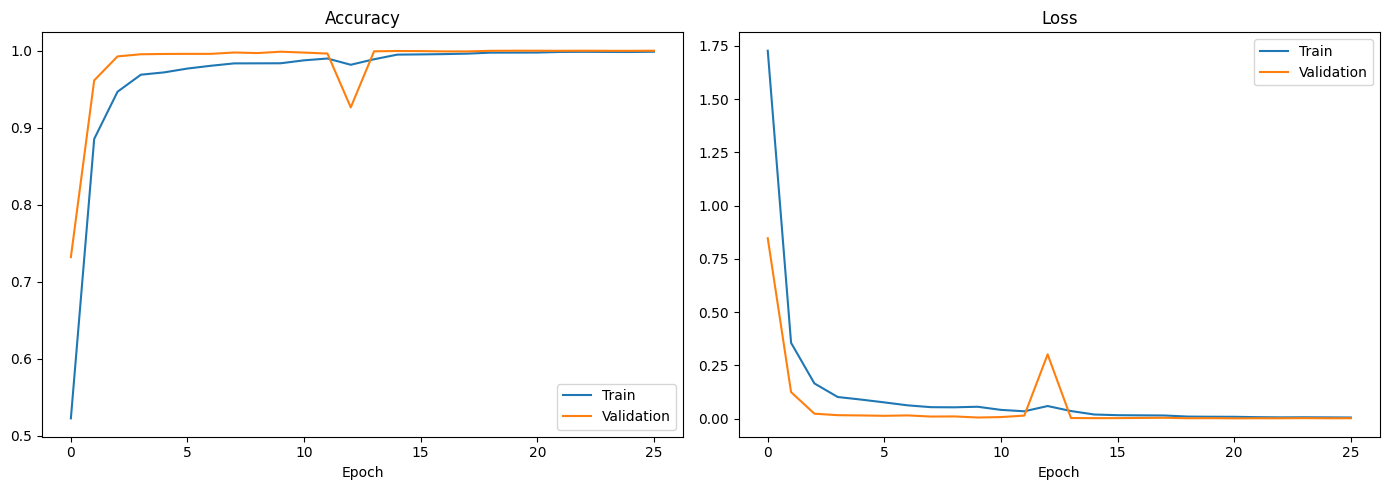

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Accuracy Grafiği
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss Grafiği
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Test setinde tahmin

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # olasılıktan sınıfa çevir
y_true_classes = np.argmax(y_test_ohe, axis=1) # one-hot'tan sınıfa çevir


# Genel doğruluk

test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Test Loss : 0.0237
Test Accuracy : 0.9926 (99.26%)


In [ ]:
# Classification Report

print("\nClassification Report :")
print(classification_report(y_true_classes, y_pred_classes))


Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.99      1.00      0.99       720
           2       1.00      0.99      1.00       750
           3       1.00      0.98      0.99       450
           4       1.00      0.99      1.00       660
           5       0.99      1.00      0.99       630
           6       0.99      0.98      0.99       150
           7       1.00      1.00      1.00       450
           8       1.00      0.99      1.00       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       1.00      1.00      1.00       420
          12       1.00      0.99      0.99       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.99      1.00      0.99       210
          16       1.00      1.00      1.00       150
  

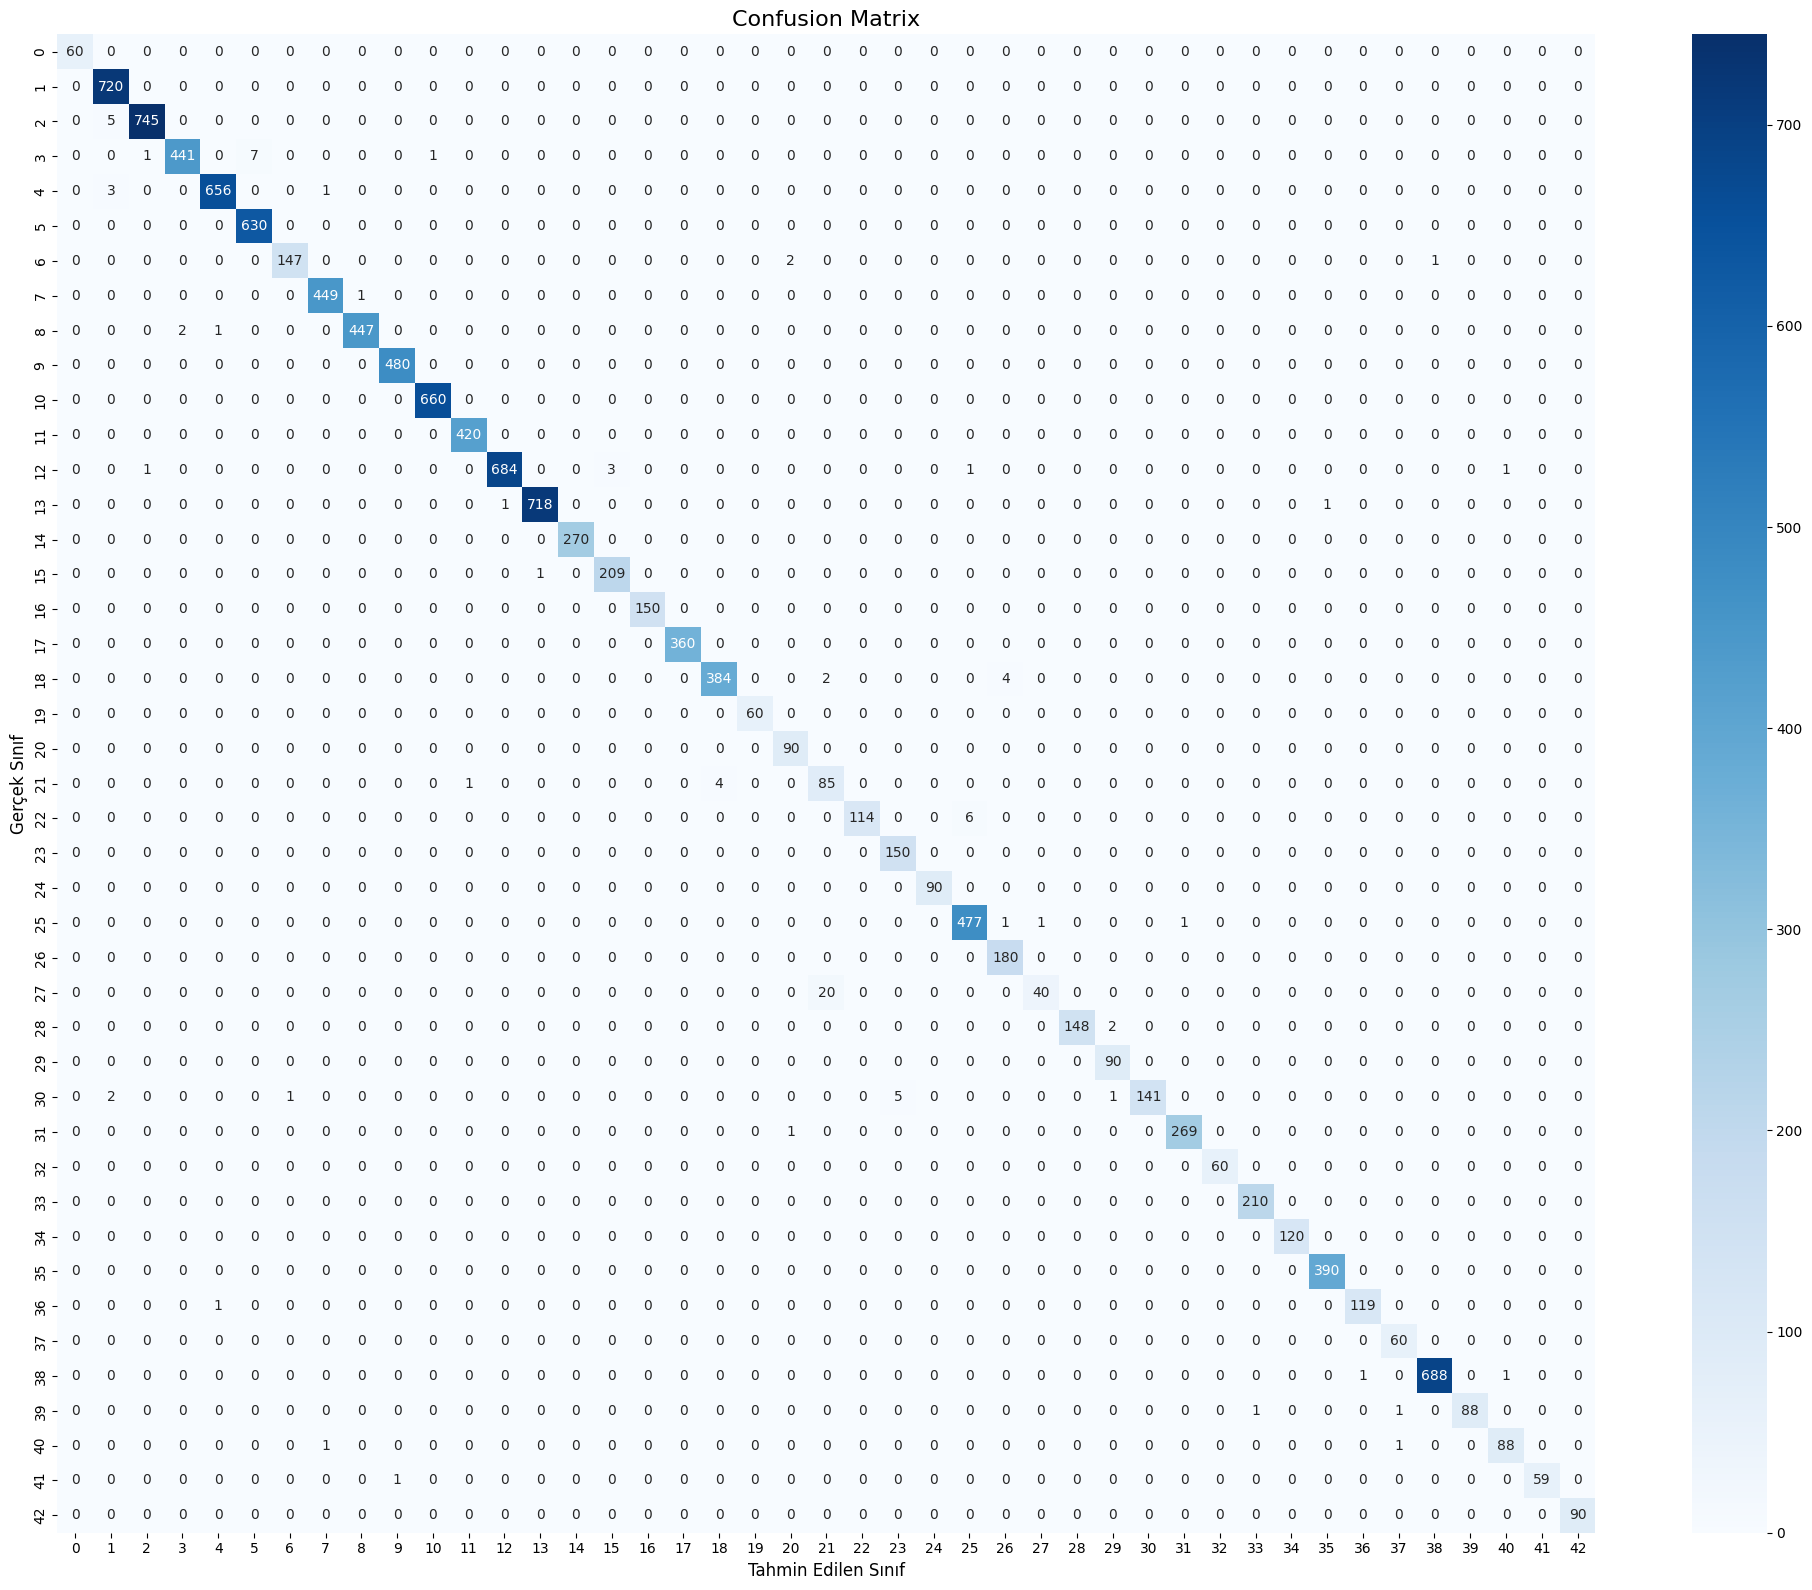

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(20,16))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=range(43),
            yticklabels=range(43))

plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Gerçek Sınıf", fontsize=12)
plt.xlabel("Tahmin Edilen Sınıf", fontsize=12)
plt.tight_layout()
plt.show()


Yanlış tahmin sayısı : 94
Doğru tahmin sayısı : 12536


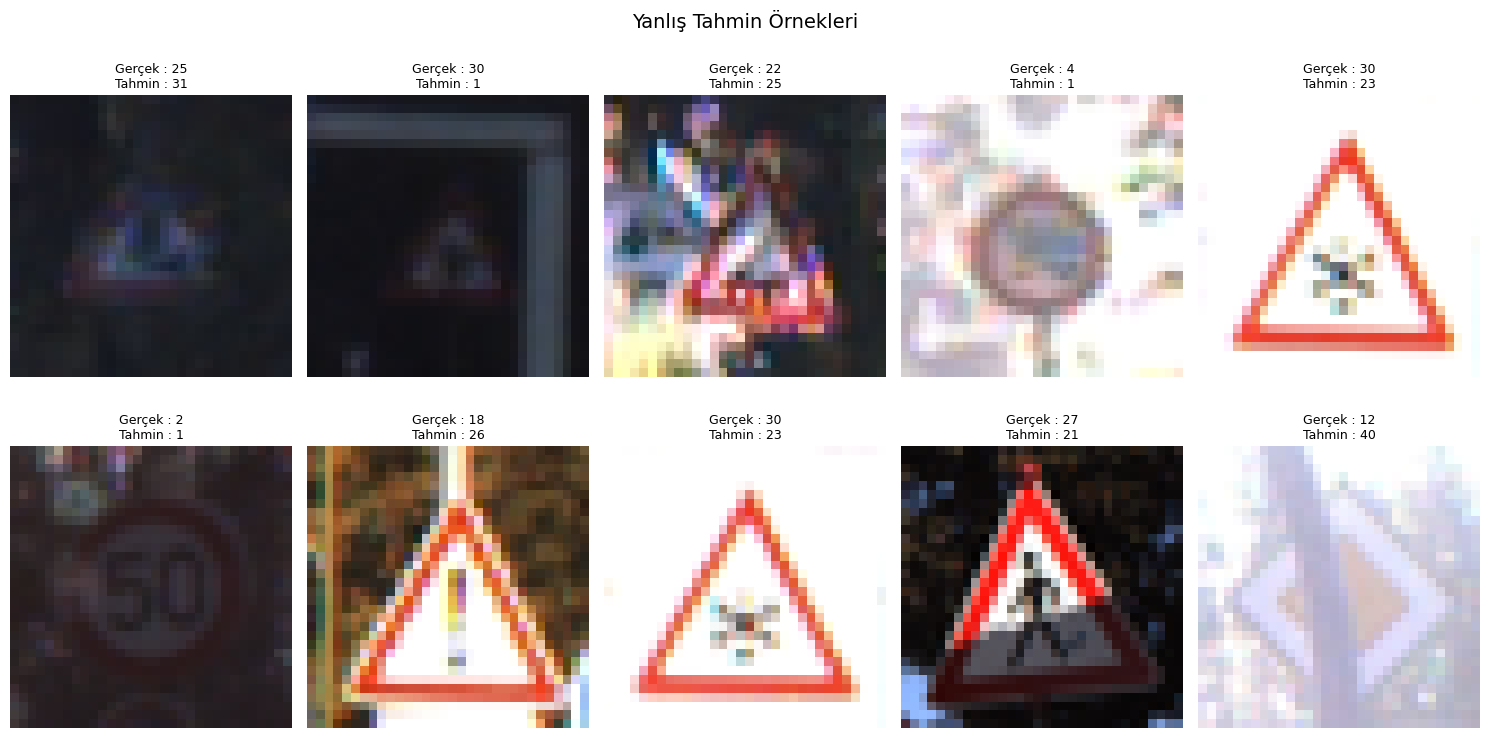

In [ ]:
# Yanlış Tahminleri Göster

wrong_idx = np.where(y_pred_classes != y_true_classes)[0]
print(f"\nYanlış tahmin sayısı : {len(wrong_idx)}")
print(f"Doğru tahmin sayısı : {len(y_true_classes) - len(wrong_idx)}")

# 10 yanlış tahmini görselleştir

fig, axes = plt.subplots(2,5,figsize=(15,8))
axes = axes.flatten()

for i, idx in enumerate(wrong_idx[:10]):
  axes[i].imshow(X_test[idx])
  axes[i].set_title(f"Gerçek : {y_true_classes[idx]}\nTahmin : {y_pred_classes[idx]}", fontsize=9)
  axes[i].axis('off')

plt.suptitle('Yanlış Tahmin Örnekleri', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
## Modeli Kaydet

model.save('trafik_levhasi_modeli.keras')
print("Model kaydedildi.")

files.download('trafik_levhasi_modeli.keras')

Model kaydedildi.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
## Modeli Yükle

loaded_model = load_model('trafik_levhasi_modeli.keras')

In [ ]:
class_names = {
    0: '20 km/h', 1: '30 km/h', 2: '50 km/h', 3: '60 km/h',
    4: '70 km/h', 5: '80 km/h', 6: '80 km/h sonu', 7: '100 km/h',
    8: '120 km/h', 9: 'Geçiş yasağı', 10: '3.5t geçiş yasağı',
    11: 'Öncelikli kavşak', 12: 'Öncelikli yol', 13: 'Yol ver',
    14: 'Dur', 15: 'Araç giremez', 16: '3.5t giremez',
    17: 'Girilmez', 18: 'Genel tehlike', 19: 'Sol viraj',
    20: 'Sağ viraj', 21: 'Çift viraj', 22: 'Kasis',
    23: 'Kaygan yol', 24: 'Sağda daralma', 25: 'Yol çalışması',
    26: 'Trafik ışığı', 27: 'Yaya geçidi', 28: 'Okul geçidi',
    29: 'Bisiklet geçidi', 30: 'Buzlu yol', 31: 'Hayvan geçidi',
    32: 'Kısıtlama sonu', 33: 'Sağa dön', 34: 'Sola dön',
    35: 'Düz git', 36: 'Düz veya sağa', 37: 'Düz veya sola',
    38: 'Sağdan geç', 39: 'Soldan geç', 40: 'Dönel kavşak',
    41: 'Geçiş yasağı sonu', 42: 'Tır geçiş yasağı sonu'
}

In [ ]:
def predict_image(img_path, model, class_names, img_size=32):
  img = Image.open(img_path).convert('RGB')
  img_resized = img.resize((img_size, img_size))
  img_array = np.array(img_resized, dtype='float32') / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  # Tahmin
  predictions = model.predict(img_array, verbose=0)
  predicted_class = np.argmax(predictions)
  confidence = predictions[0][predicted_class]*100

  # Görselleştirme
  plt.figure(figsize=(6,4))
  plt.imshow(img)
  plt.title(f"Tahmin : {class_names[predicted_class]} \nGüven: %{confidence:.2f}", fontsize=13)
  plt.axis('off')
  plt.show()

  print(f"Tahmin edilen sınıf: {predicted_class} - {class_names[predicted_class]}")
  print(f"Güven oranı: %{confidence:.2f}")

  return predicted_class, confidence

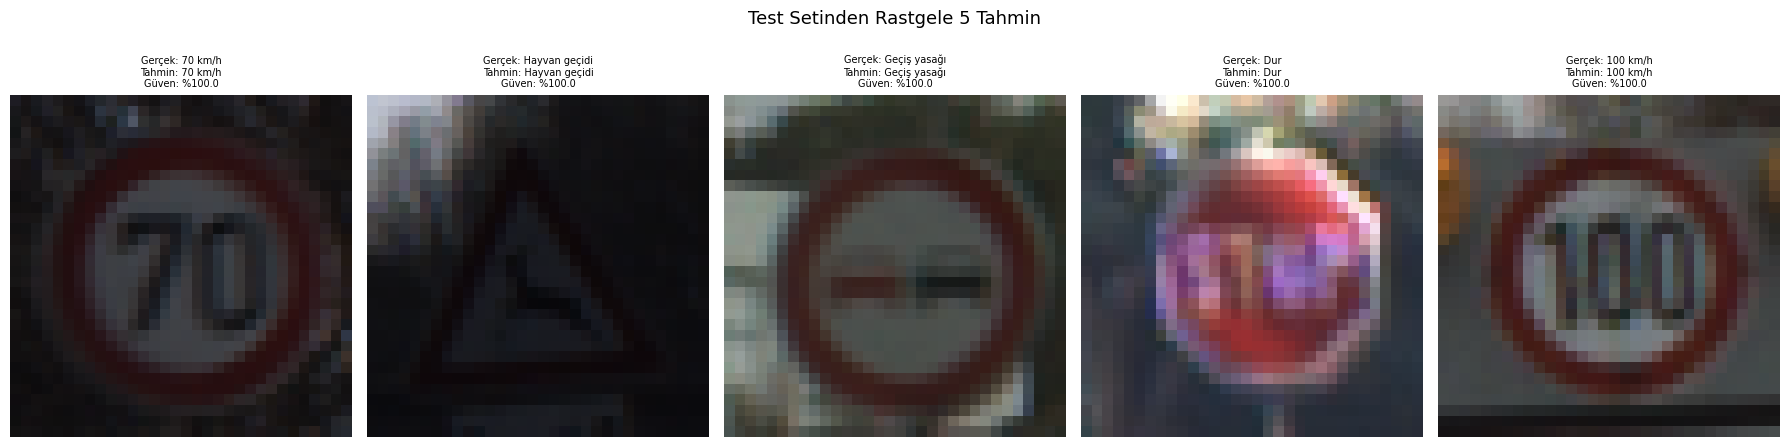

In [ ]:
# Test setinden rastgele 5 görüntü seç, tahmin et.

random_idx = np.random.choice(len(X_test), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(18,5))

for i, idx in enumerate(random_idx):
  img = X_test[idx]
  true_label = y_true_classes[idx]

  pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
  pred_class = np.argmax(pred)
  confidence = pred[0][pred_class]*100

  axes[i].imshow(img)
  axes[i].set_title(
      f"Gerçek: {class_names[true_label]}\n"
      f"Tahmin: {class_names[pred_class]}\n"
      f"Güven: %{confidence:.1f}",
      fontsize=7
  )

  axes[i].axis('off')

plt.suptitle("Test Setinden Rastgele 5 Tahmin", fontsize=13)
plt.tight_layout()
plt.show()